In [ ]:

import shutil
# Unzip 'file.zip' to a specific directory '/path/to/destination'
shutil.unpack_archive('./data/ieee-fraud-detection.zip', extract_dir='./data/BD')

# Fraud Detection — End-to-End ML Pipeline

> Identifying fraudulent transactions in real-time using supervised learning on anonymised identity and device signals.

---

## Background

Financial fraud costs the global economy hundreds of billions of dollars annually. As payment systems grow faster and more automated, so do the techniques used to exploit them — card testing, account takeover, synthetic identity fraud, and velocity attacks are now largely bot-driven and operate at machine speed.

Rule-based systems (block if amount > $X, flag if country changes) remain useful but brittle. They require constant manual tuning, leak false positives at scale, and are trivially bypassed once attackers learn the thresholds. Machine learning offers a complementary layer: models that learn latent patterns across hundreds of features simultaneously, generalise to unseen attack vectors, and improve as more labelled data accumulates.

This notebook develops that layer end-to-end: from raw, joined data through preprocessing, modelling, evaluation, and interpretation.

---

## Problem Statement

This is a **binary classification** problem. Given a transaction and its associated signals, the objective is to determine:

$$\hat{y} = \begin{cases} 1 & \text{fraudulent} \\ 0 & \text{legitimate} \end{cases}$$

Two structural challenges define the modelling approach throughout:

| Challenge | Description | Implication |
|---|---|---|
| **Class imbalance** | Fraud represents ~0.5% of transactions | Accuracy is misleading; optimise for Precision-Recall AUC |
| **Concept drift** | Fraud patterns evolve as attackers adapt | Models require monitoring and periodic retraining |

--

## Dataset

The dataset is assembled from two source tables joined on `TransactionID`.

```
train_transaction.csv  ──┐
                          ├── JOIN on TransactionID ──► Full dataset
train_identity.csv     ──┘
```

| Table | Rows | Columns | Memory | Coverage |
|---|---|---|---|---|
| **Transaction** | 590,540 | 394 | 1.7 GB | All transactions |
| **Identity** | 144,233 | 41 | 45.1 MB | ~24% of transactions |

**Transaction table** contains core attributes (timing, amount, card and address fields) plus `V1`–`V339`, a block of anonymised Vesta-engineered features encoding aggregated behavioural signals — transaction frequency, amount statistics, and time-windowed counts.

**Identity table** contains `id_01`–`id_38` (anonymised identity signals) and device metadata (`DeviceType`, `DeviceInfo`). Its partial coverage means identity columns will be null for ~76% of rows after joining — this is structural, not random, and is treated accordingly.

---

## Notebook Structure

```
├── 1. Data Loading & Inspection
│   └── Schema review, dtypes, and memory optimization
├── 2. Exploratory Data Analysis (EDA)
│   ├── Target distribution & class imbalance analysis
│   ├── Structural missingness profiling
│   └── Feature distributions & correlation analysis by fraud label
├── 3. Preprocessing & Data Cleaning
│   ├── Missing value strategies (Imputation vs. Indicator flags)
│   ├── Categorical encoding (Target, Frequency, and One-Hot)
│   └── Feature scaling for baseline models
├── 4. Feature Engineering
│   ├── Missingness indicator flags
│   ├── Device parsing (Extracting OS/Browser from DeviceInfo)
│   └── Interaction features (e.g., TransactionAmt relative to group means)
├── 5. Modeling Pipeline
│   ├── Baseline Model (Regularized Logistic Regression)
│   ├── Advanced Gradient Boosting (XGBoost / LightGBM)
│   └── Imbalance Handling (Cost-sensitive learning, SMOTE, Threshold tuning)
├── 6. Evaluation Metric Suite
│   ├── Precision, Recall, and F1-score (per-class breakdown)
│   ├── ROC-AUC vs. Precision-Recall (PR) curves
│   └── Confusion matrix analysis across custom decision thresholds
├── 7. Model Interpretability & XAI
│   ├── Global feature importance (Gain, Split, and SHAP values)
│   └── Error Analysis (Deep dive into False Negatives)
└── 8. Production & Deployment Considerations
    └── Cost-optimized threshold selection & retraining strategies
```

---

## Evaluation Strategy

Due to the extreme class imbalance, traditional accuracy is discarded for model selection. Instead, we evaluate performance using:

- **Precision-Recall AUC** — Our primary metric. Captures model performance across all thresholds without being artificially inflated by the massive majority class.
- **F1-score (fraud class)** — harmonic mean of precision and recall; penalises both false positives and false negatives.
- **ROC-AUC** — Utilized as a secondary metric to evaluate overall model ranking capacity.

⚠️ **Business Alignment:** The default classification threshold of 0.5 will be explicitly tuned. In fraud detection, the financial cost of a missed fraud (False Negative) is vastly higher than the operational cost of a manual review alert (False Positive). The final decision threshold is optimized to minimize total business cost rather than purely mathematical error.

In [ ]:
# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_recall_curve, confusion_matrix)
from imblearn.over_sampling import SMOTE

# Gradient boosting
import lightgbm as lgb
import xgboost as xgb

# Interpretability
import shap

# Step 1 — Data Loading & Inspection

## Objective
Load both source tables, join them correctly, understand the schema, and optimise memory before any further work. Everything downstream depends on this step being done right.

---

## 1.1 — Load & Join

The dataset lives in two files. The transaction table holds all 590,540 records. The identity table holds enriched signals for a subset of 144,233 of them. The join must be a **left join**, preserving every transaction regardless of whether identity data exists.


In [ ]:
train_txn = pd.read_csv('./data/BD/train_transaction.csv')
train_id  = pd.read_csv('./data/BD/train_identity.csv')

original_df = train_txn.merge(train_id, on='TransactionID', how='left')

print(f"Transaction table : {train_txn.shape}")
print(f"Identity table    : {train_id.shape}")
print(f"Joined table      : {original_df.shape}")

Transaction table : (590540, 394)
Identity table    : (144233, 41)
Joined table      : (590540, 434)


**Why left join?** An inner join would silently drop the 76% of transactions without identity data, removing the majority of your training rows and introducing selection bias.

---
## 1.2 — Memory Optimisation

The joined frame is ~2.6 GB in default float64. Every subsequent operation — groupby aggregations, new columns, copies — multiplies that cost. Downcasting to float32 and int32 halves memory with zero information loss for this dataset.

In [ ]:
def reduce_memory(df: pd.DataFrame) -> pd.DataFrame:
    before = df.memory_usage(deep=True).sum() / 1e9

    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes('int64').columns:
        df[col] = df[col].astype('int32')

    after = df.memory_usage(deep=True).sum() / 1e9
    print(f"Memory reduced: {before:.2f} GB → {after:.2f} GB ({(1 - after/before)*100:.0f}% reduction)")
    return df

original_df = reduce_memory(original_df)
df = original_df.copy()

# Add:
del original_df  # frees ~1.3GB immediately
del train_txn, train_id
import gc; gc.collect()

Memory reduced: 2.64 GB → 1.68 GB (36% reduction)


30

## 1.3 — Schema Review

Build a single summary DataFrame covering every column at once. This is faster than calling `.info()`, `.describe()`, and `.isnull()` separately.

In [ ]:
summary = pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulls'   : df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2),
    'nunique' : df.nunique(),
    'sample'  : df.iloc[0]
}).sort_values('null_pct', ascending=False)

print(summary.to_string())

                  dtype   nulls  null_pct  nunique    sample
id_24           float32  585793     99.20       12       NaN
id_21           float32  585381     99.13      490       NaN
id_07           float32  585385     99.13       84       NaN
id_25           float32  585408     99.13      341       NaN
id_26           float32  585377     99.13       95       NaN
id_08           float32  585385     99.13       94       NaN
id_27            object  585371     99.12        2       NaN
id_23            object  585371     99.12        3       NaN
id_22           float32  585371     99.12       25       NaN
dist2           float32  552913     93.63     1751       NaN
D7              float32  551623     93.41      597       NaN
id_18           float32  545427     92.36       18       NaN
D13             float32  528588     89.51      577       NaN
D14             float32  528353     89.47      802       NaN
D12             float32  525823     89.04      635       NaN
id_04           float32 

**Data Integrity Validation**

Prior to any transformation, the following assertions must be verified programmatically rather than through visual inspection alone. Each check enforces a structural guarantee that downstream modelling depends on:

In [ ]:
# No duplicate transaction IDs
assert df['TransactionID'].duplicated().sum() == 0, "Duplicate TransactionIDs found"

# Target is strictly binary
assert set(df['isFraud'].unique()).issubset({0, 1}), "isFraud contains unexpected values"

# Identity coverage
coverage = df['id_01'].notnull().mean()
print(f"Transactions with identity data: {coverage:.1%}")

# Target distribution
print(df['isFraud'].value_counts(normalize=True).round(4))

Transactions with identity data: 24.4%
isFraud
0    0.965
1    0.035
Name: proportion, dtype: float64


**Schema Review — Key Observations**

The summary output should be examined for the following structural properties before any transformation is applied. Columns with zero nulls beyond `TransactionID` and `isFraud` are complete and can be used without modification. Columns exceeding 90% missingness are candidates for removal, as the signal-to-noise ratio is insufficient to justify retention. Any column where `nunique == 1` carries zero variance and should be dropped immediately. String columns with an unexpectedly low unique count may indicate categorical collapse or data entry inconsistencies and warrant consolidation before encoding.

---

# Step 2 — Exploratory Data Analysis

## Objective

Exploratory analysis precedes all transformation and modelling decisions. This step is structured around four diagnostic questions that must be answered before any preprocessing begins: how severe is the class imbalance and does it vary over time; where is data absent and does that absence carry predictive signal; how do feature distributions differ between the fraud and legitimate classes; and which V-features are statistically redundant and safe to remove without information loss.

---

## 2.1 — Target Distribution & Class Imbalance

The target variable confirms a pronounced class imbalance. Legitimate transactions account for 96.5% of all records, with fraud representing the remaining 3.5%. This ratio has two direct consequences for the modelling approach: raw accuracy is a misleading performance metric, as a model predicting the majority class unconditionally achieves 96.5% accuracy without any discriminative ability; and standard loss functions optimise for the majority class by default, requiring explicit correction through class weighting, resampling, or threshold adjustment.

```
isFraud
0    0.965    →  569,877 transactions
1    0.035    →   20,663 transactions
```

Identity data is present for 24.4% of transactions — 144,233 records out of 590,540. For the remaining 75.6%, all `id_*` columns will be null following the join. This is a structural property of the dataset, not a data quality issue, and must be treated accordingly during preprocessing.

> **Modelling implication:** Standard accuracy is not a valid optimisation target for this dataset. All model selection and threshold decisions must be based on Precision-Recall AUC and the fraud-class F1-score.

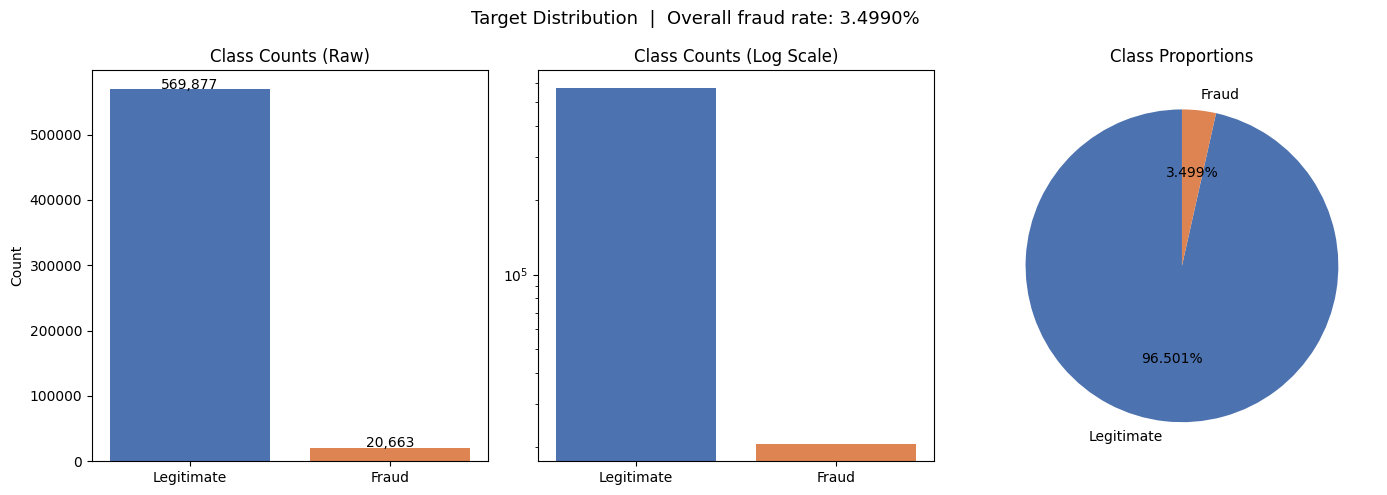

In [ ]:
import matplotlib.gridspec as gridspec

fraud_rate = df['isFraud'].mean()
counts = df['isFraud'].value_counts()

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# Raw counts
ax1 = fig.add_subplot(gs[0])
ax1.bar(['Legitimate', 'Fraud'], counts.values, color=['#4C72B0', '#DD8452'])
ax1.set_title('Class Counts (Raw)')
ax1.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Log scale — makes the fraud bar visible
ax2 = fig.add_subplot(gs[1])
ax2.bar(['Legitimate', 'Fraud'], counts.values, color=['#4C72B0', '#DD8452'], log=True)
ax2.set_title('Class Counts (Log Scale)')

# Pie chart
ax3 = fig.add_subplot(gs[2])
ax3.pie(counts.values, labels=['Legitimate', 'Fraud'],
        colors=['#4C72B0', '#DD8452'], autopct='%1.3f%%', startangle=90)
ax3.set_title('Class Proportions')

plt.suptitle(f'Target Distribution  |  Overall fraud rate: {fraud_rate:.4%}', fontsize=13)
plt.tight_layout()

**Distribution of Fraud rate over time**

Before splitting the data, it is important to verify that fraud is evenly distributed over time rather than concentrated in a specific period. If fraud patterns shift across the observation window — which is common, as attack methods evolve — a random split will expose the model to future fraud patterns during training, producing evaluation results that are more optimistic than what would be achieved in production. A time-based split, training on earlier data and evaluating on later data, more accurately reflects real deployment conditions and should be preferred if any temporal trend is detected.

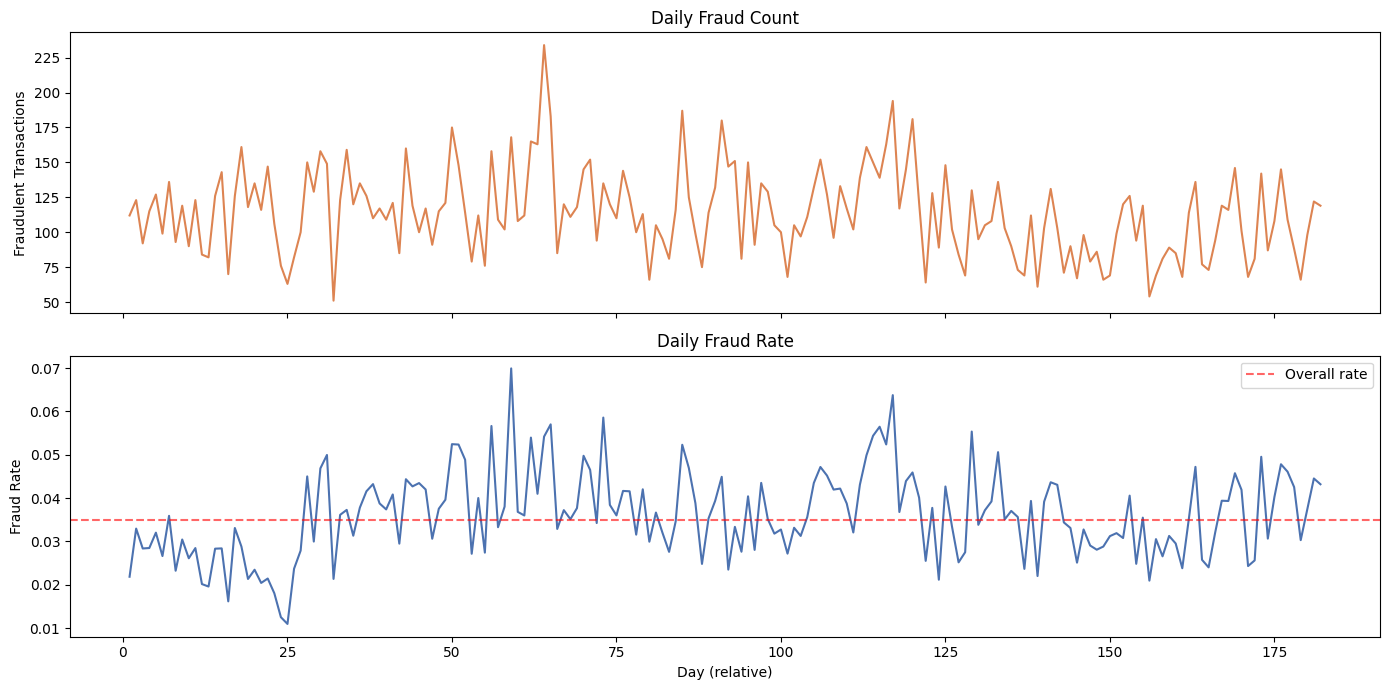

In [ ]:
df['day'] = df['TransactionDT'] // (3600 * 24)

daily = df.groupby('day')['isFraud'].agg(
    fraud_count='sum',
    total='count',
    fraud_rate='mean'
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(daily['day'], daily['fraud_count'], color='#DD8452')
ax1.set_title('Daily Fraud Count')
ax1.set_ylabel('Fraudulent Transactions')

ax2.plot(daily['day'], daily['fraud_rate'], color='#4C72B0')
ax2.axhline(fraud_rate, color='red', linestyle='--', alpha=0.6, label='Overall rate')
ax2.set_title('Daily Fraud Rate')
ax2.set_ylabel('Fraud Rate')
ax2.set_xlabel('Day (relative)')
ax2.legend()
plt.tight_layout()
plt.show()

> **What to look for:** If fraud rate trends upward over time, a random train/test split will leak future patterns into training. Use a **time-based split** instead — train on earlier days, test on later days.

---

## 2.2 — Structural Missingness Profiling

This is the most critical EDA step given the dataset structure. Missingness here is not random — it has distinct causes that inform how to handle it.

In [ ]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# Assign to tiers
tier_drop   = missing_pct[missing_pct > 90].index.tolist()
tier_flag   = missing_pct[(missing_pct > 20) & (missing_pct <= 90)].index.tolist()
tier_impute = missing_pct[(missing_pct > 0)  & (missing_pct <= 20)].index.tolist()
tier_complete = missing_pct[missing_pct == 0].index.tolist()

print(f"Complete (0% null)      : {len(tier_complete):>4} columns")
print(f"Impute  (<20% null)     : {len(tier_impute):>4} columns")
print(f"Flag    (20–90% null)   : {len(tier_flag):>4} columns")
print(f"Drop    (>90% null)     : {len(tier_drop):>4} columns")


Complete (0% null)      :   21 columns
Impute  (<20% null)     :  162 columns
Flag    (20–90% null)   :  240 columns
Drop    (>90% null)     :   12 columns


**Visualise the missingness pattern** — the heatmap reveals which columns are missing together, confirming the structural groups:

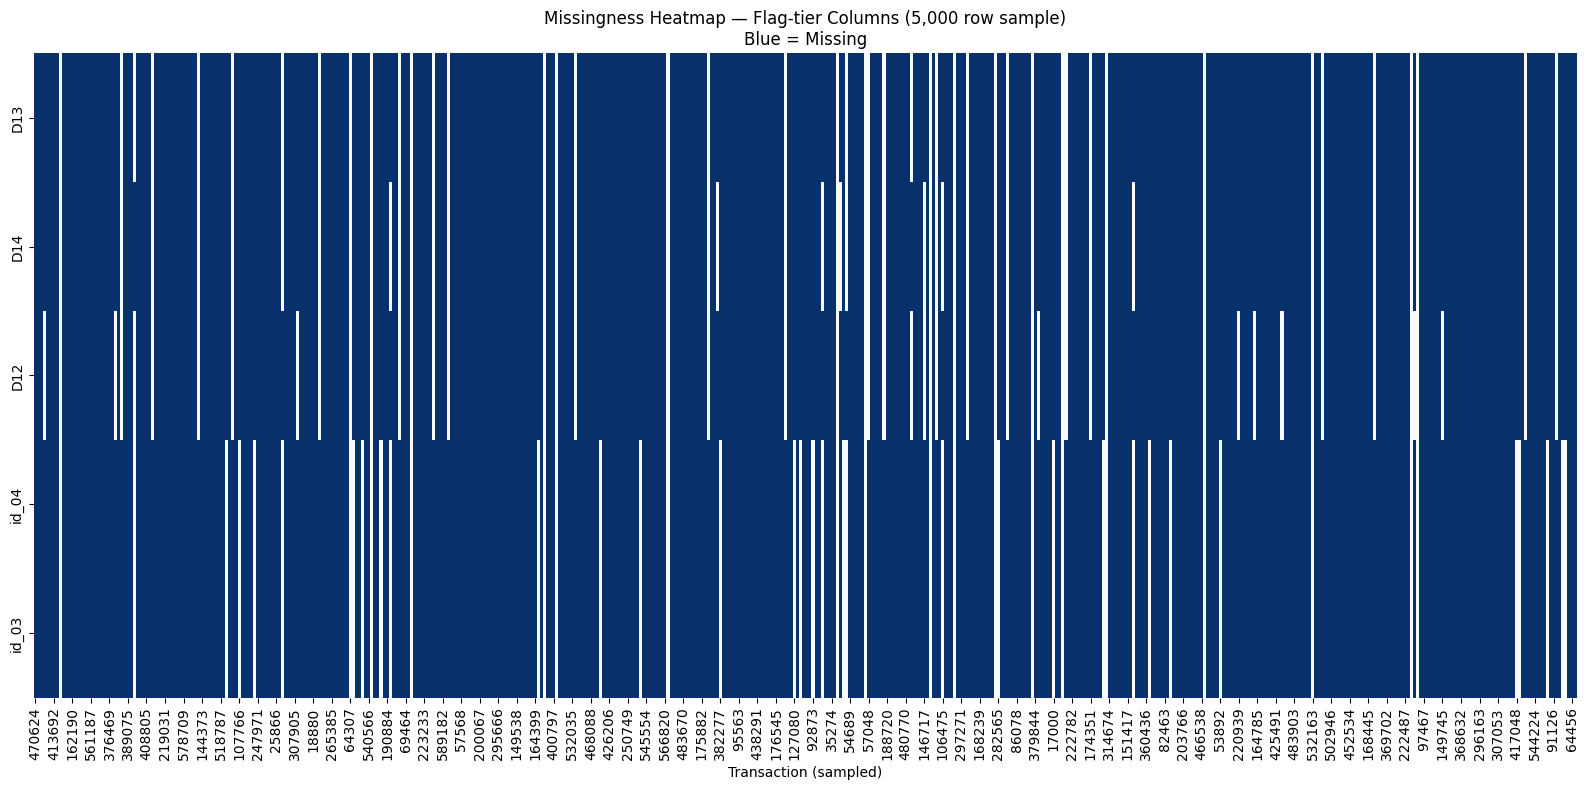

In [ ]:
# Sample to keep the plot manageable
sample = df[tier_flag[:5]].sample(500, random_state=42).isnull().astype(int)

plt.figure(figsize=(16, 8))
sns.heatmap(sample.T, cbar=False, cmap='Blues', yticklabels=True)
plt.title('Missingness Heatmap — Flag-tier Columns (5,000 row sample)\nBlue = Missing')
plt.xlabel('Transaction (sampled)')
plt.tight_layout()
plt.show()


**The key question: does missingness predict fraud?**

In [ ]:
print(f"\n{'Column':<15} {'Missing→Fraud':>14} {'Present→Fraud':>14} {'Delta':>10}")
print("─" * 58)

for col in sorted(tier_flag):
    fraud_missing = df.loc[df[col].isnull(), 'isFraud'].mean()
    fraud_present = df.loc[df[col].notnull(), 'isFraud'].mean()
    delta = fraud_missing - fraud_present
    flag = " ◄" if abs(delta) > 0.01 else ""
    print(f"{col:<15} {fraud_missing:>14.4f} {fraud_present:>14.4f} {delta:>+10.4f}{flag}")



Column           Missing→Fraud  Present→Fraud      Delta
──────────────────────────────────────────────────────────
D11                     0.0521         0.0196    +0.0325 ◄
D12                     0.0248         0.1174    -0.0926 ◄
D13                     0.0262         0.1104    -0.0842 ◄
D14                     0.0255         0.1160    -0.0905 ◄
D2                      0.0456         0.0254    +0.0202 ◄
D3                      0.0420         0.0294    +0.0127 ◄
D4                      0.0361         0.0346    +0.0015
D5                      0.0316         0.0388    -0.0072
D6                      0.0250         0.1055    -0.0804 ◄
D8                      0.0249         0.1045    -0.0796 ◄
D9                      0.0249         0.1045    -0.0796 ◄
DeviceInfo              0.0255         0.0725    -0.0470 ◄
DeviceType              0.0210         0.0796    -0.0586 ◄
M1                      0.0528         0.0199    +0.0330 ◄
M2                      0.0528         0.0199    +0.0330 ◄
M3

> Any column where `|Delta| > 0.01` carries predictive signal in its missingness alone. These **must** receive an indicator flag before imputation — not just imputation.

---

## 2.3 — Feature Distributions by Fraud Label

**TransactionAmt** — the most interpretable continuous feature:

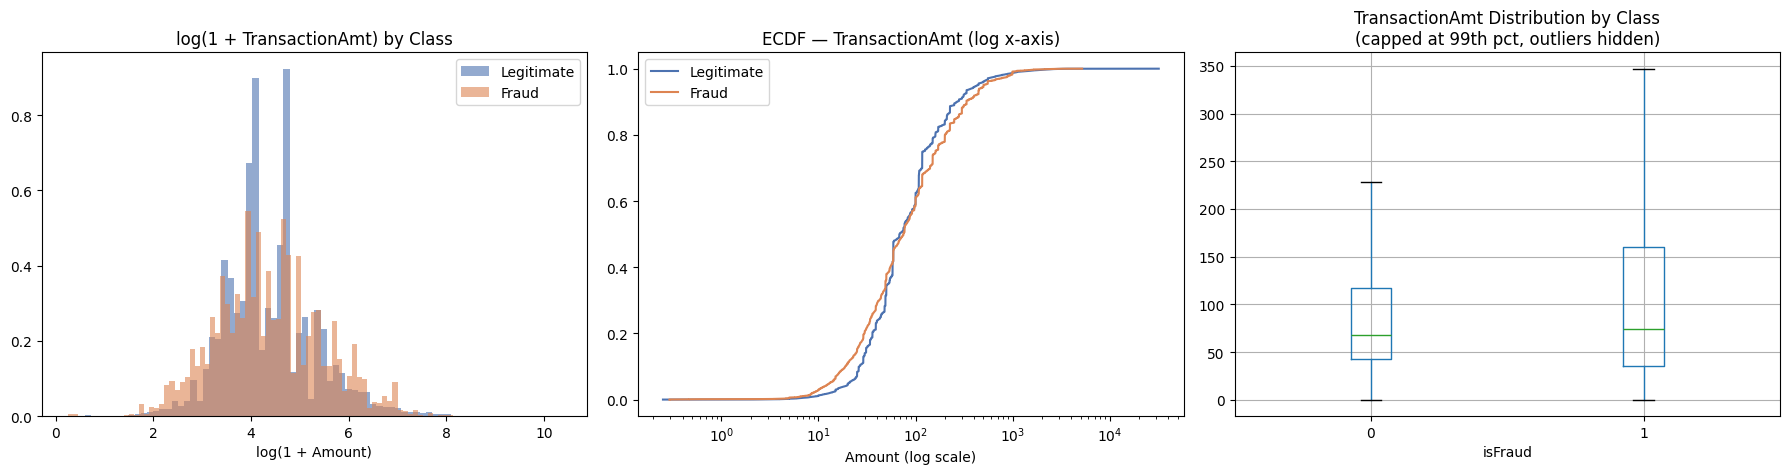

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fraud    = df[df['isFraud'] == 1]['TransactionAmt']
legit    = df[df['isFraud'] == 0]['TransactionAmt']

# Log-transformed distributions
axes[0].hist(np.log1p(legit),  bins=80, alpha=0.6, label='Legitimate', density=True, color='#4C72B0')
axes[0].hist(np.log1p(fraud),  bins=80, alpha=0.6, label='Fraud',      density=True, color='#DD8452')
axes[0].set_title('log(1 + TransactionAmt) by Class')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].legend()

# ECDF
for label, grp, color in [(0, legit, '#4C72B0'), (1, fraud, '#DD8452')]:
    x = np.sort(grp)
    y = np.arange(1, len(x)+1) / len(x)
    axes[1].plot(x, y, label=['Legitimate', 'Fraud'][label], color=color)
axes[1].set_xscale('log')
axes[1].set_title('ECDF — TransactionAmt (log x-axis)')
axes[1].set_xlabel('Amount (log scale)')
axes[1].legend()

# Box plot (capped at 99th percentile)
cap = df['TransactionAmt'].quantile(0.99)
df_capped = df[df['TransactionAmt'] <= cap]
df_capped.boxplot(column='TransactionAmt', by='isFraud', ax=axes[2], showfliers=False)
axes[2].set_title('TransactionAmt Distribution by Class\n(capped at 99th pct, outliers hidden)')
axes[2].set_xlabel('isFraud')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Summary statistics
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))


**Categorical features — fraud rate per category:**

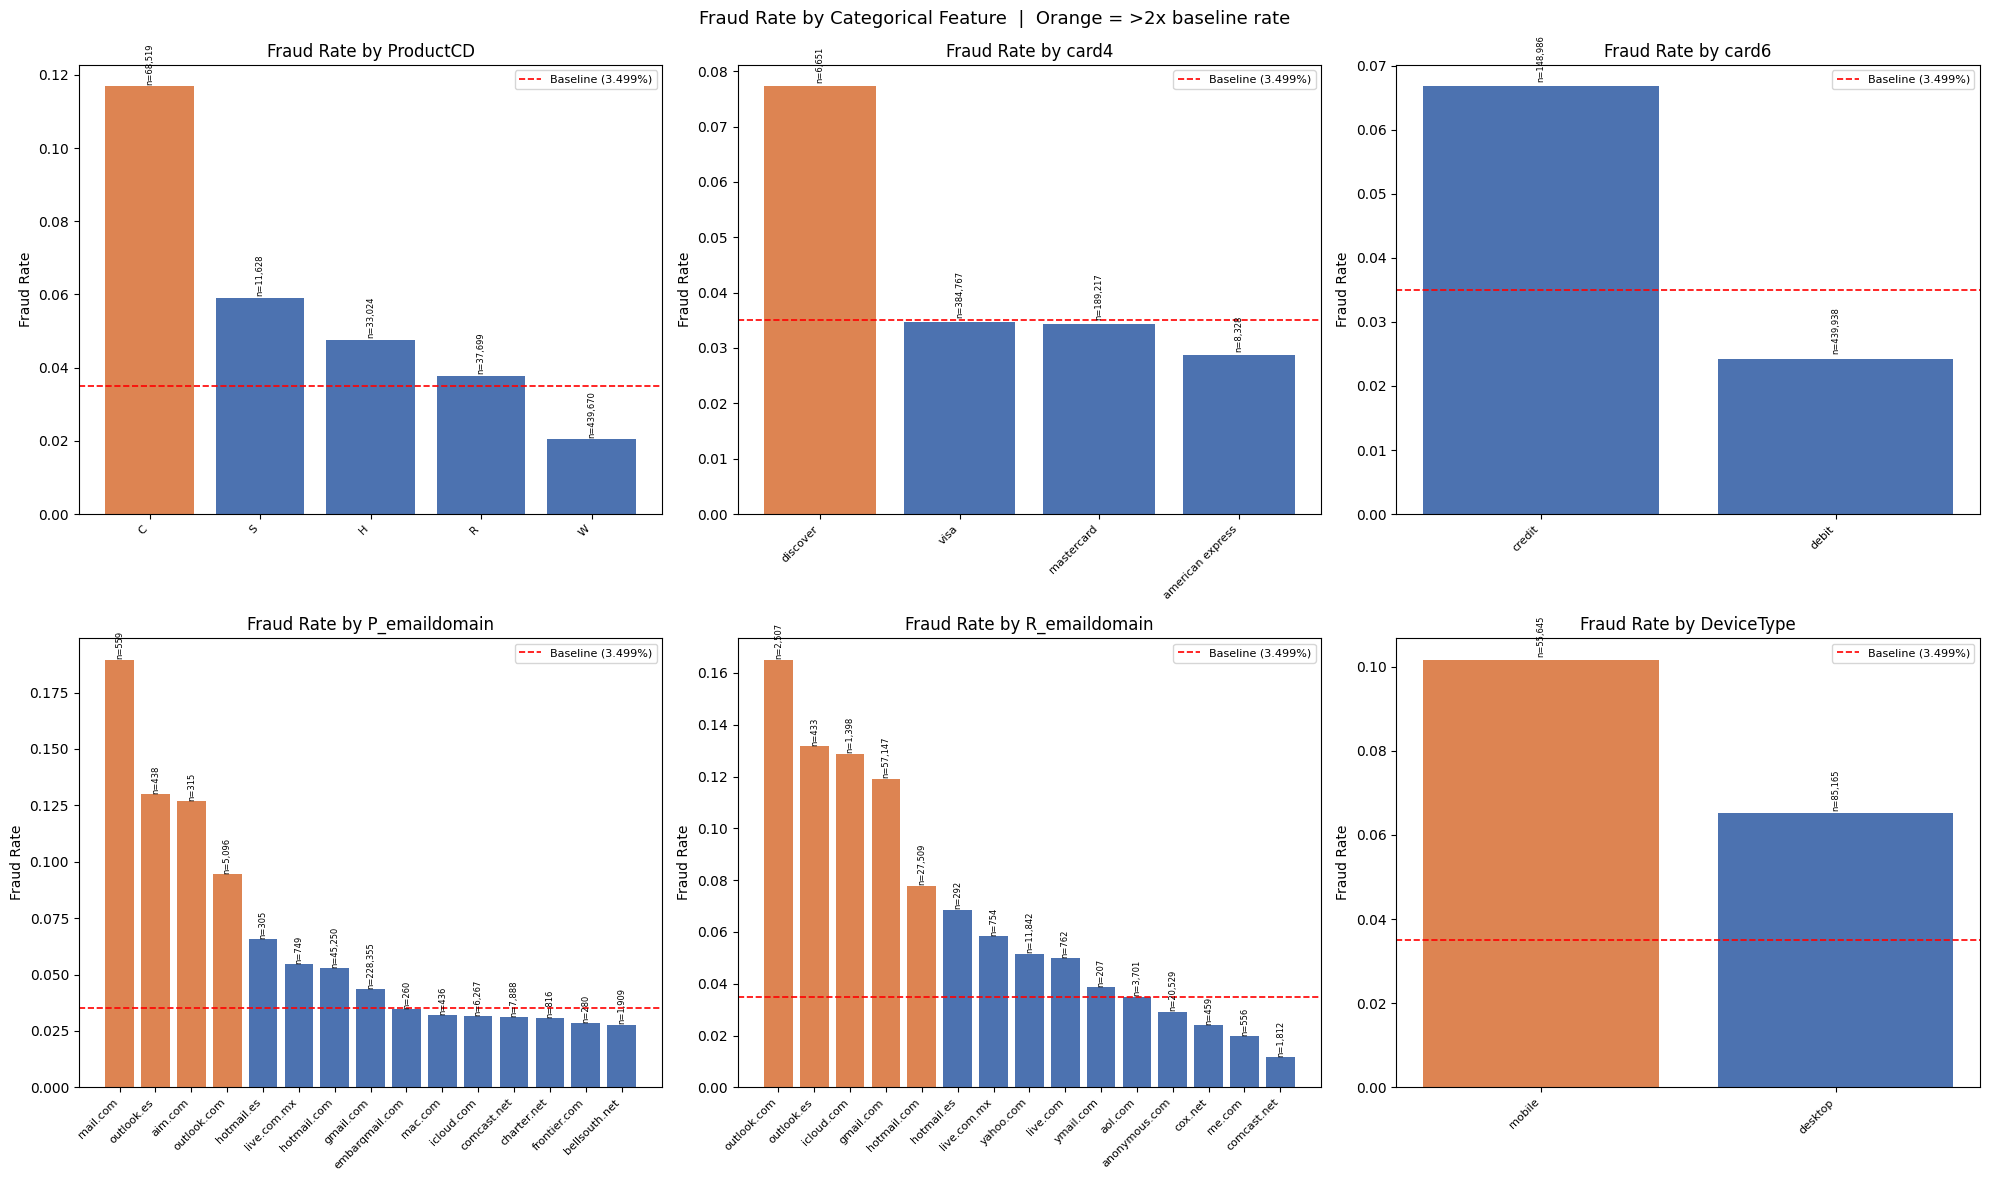

In [ ]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stats = (df.groupby(col)['isFraud']
               .agg(fraud_rate='mean', n='count')
               .query('n > 200')
               .sort_values('fraud_rate', ascending=False)
               .head(15))  # cap at 15 categories for readability

    bars = axes[i].bar(range(len(stats)), stats['fraud_rate'],
                       color=['#DD8452' if r > fraud_rate * 2 else '#4C72B0'
                              for r in stats['fraud_rate']])
    axes[i].axhline(fraud_rate, color='red', linestyle='--', linewidth=1.2,
                    label=f'Baseline ({fraud_rate:.3%})')
    axes[i].set_xticks(range(len(stats)))
    axes[i].set_xticklabels(stats.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].legend(fontsize=8)

    # Annotate bar count
    for j, (rate, n) in enumerate(zip(stats['fraud_rate'], stats['n'])):
        axes[i].text(j, rate + 0.001, f'n={n:,}', ha='center', fontsize=6, rotation=90)

plt.suptitle('Fraud Rate by Categorical Feature  |  Orange = >2x baseline rate', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
del df_capped
gc.collect()

15

---

## 2.4 — V-Feature Analysis

339 anonymous V-features can't be inspected individually. Run two analyses: correlation with the target, and inter-feature redundancy.

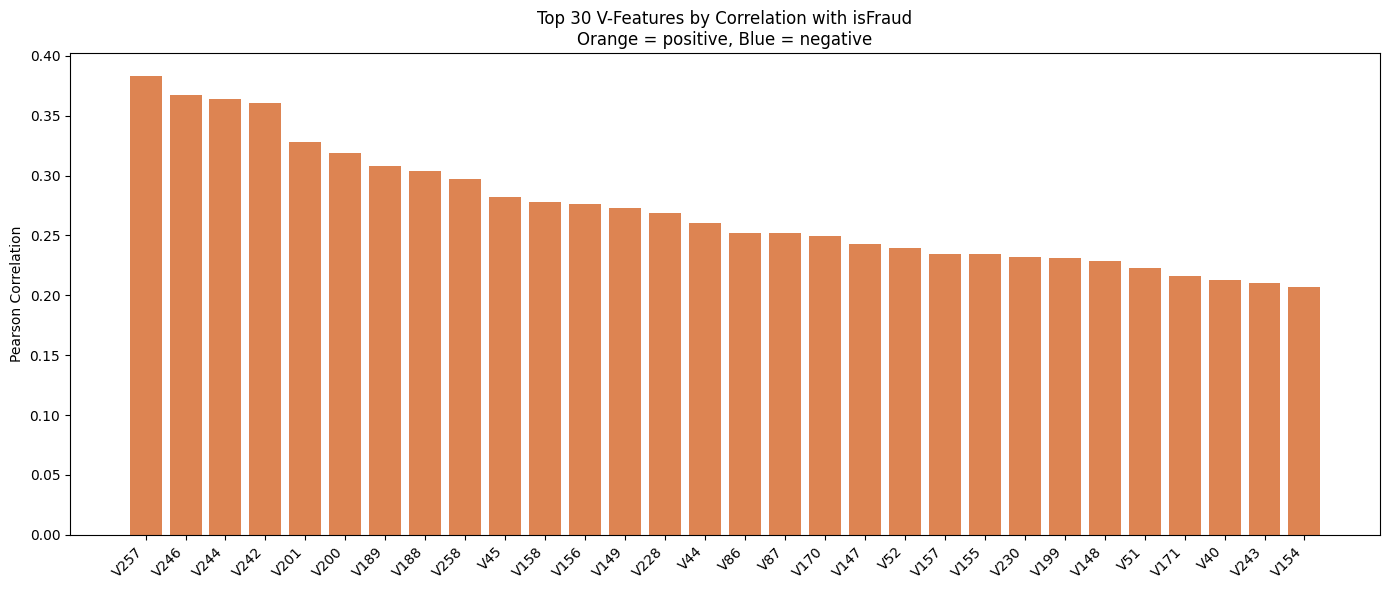

Top 10 V-features by absolute correlation with isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
Name: isFraud, dtype: float64


In [ ]:
v_cols = [c for c in df.columns if c.startswith('V')]

# ── Correlation with target ──────────────────────────────────────────────────
v_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud')
top_v  = v_corr.abs().sort_values(ascending=False).head(30)

plt.figure(figsize=(14, 6))
colors = ['#DD8452' if v_corr[c] > 0 else '#4C72B0' for c in top_v.index]
plt.bar(range(len(top_v)), top_v.values, color=colors)
plt.xticks(range(len(top_v)), top_v.index, rotation=45, ha='right')
plt.title('Top 30 V-Features by Correlation with isFraud\nOrange = positive, Blue = negative')
plt.ylabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top 10 V-features by absolute correlation with isFraud:")
print(v_corr.abs().sort_values(ascending=False).head(10))

# ── Inter-feature redundancy ─────────────────────────────────────────────────
v_corr_matrix = df[v_cols].corr().abs()

# Upper triangle only — avoid duplicate pairs
upper = v_corr_matrix.where(np.triu(np.ones(v_corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (upper.stack()
                        .reset_index()
                        .rename(columns={'level_0': 'feature_1',
                                         'level_1': 'feature_2',
                                         0: 'correlation'})
                        .query('correlation > 0.95')
                        .sort_values('correlation', ascending=False))

print(f"\nHighly correlated V-feature pairs (r > 0.95): {len(high_corr_pairs)}")
print(high_corr_pairs.head(20).to_string(index=False))

> Pairs with correlation > 0.95 are effectively duplicates. Keep the one with stronger correlation to the target and drop the other. This often eliminates 50–100 V-features before modelling.

---
---

# Step 3 — Preprocessing & Data Cleaning

## Objective
Transform raw columns into model-ready features. The order of operations within this step matters — see the sequencing note at the end.

---

## 3.1 — Drop Hopeless Columns

Columns with >90% missingness carry too little signal to justify the noise they introduce. Drop them first to reduce working memory.

In [ ]:
print(f"Dropping {len(tier_drop)} columns with >90% missing data:")
print(tier_drop)

df.drop(columns=tier_drop, inplace=True)
print(f"Remaining columns: {df.shape[1]}")
gc.collect()

Also drop zero-variance columns:

In [ ]:
zero_var = [c for c in df.columns if df[c].nunique() <= 1]
print(f"Dropping {len(zero_var)} zero-variance columns: {zero_var}")
df.drop(columns=zero_var, inplace=True)
print(f"Remaining columns: {df.shape[1]}")

And drop highly correlated V-feature duplicates identified in EDA:

In [ ]:
# From high_corr_pairs — keep feature_1 (higher target correlation), drop feature_2
redundant_v = high_corr_pairs['feature_2'].unique().tolist()
df.drop(columns=[c for c in redundant_v if c in df.columns], inplace=True)
print(f"Dropped {len(redundant_v)} redundant V-features. Remaining: {df.shape[1]}")

In [ ]:
gc.collect()

---

## 3.2 — Missing Value Strategy

**Different column groups require different strategies. Never apply a single global strategy.**

| Group | Missingness cause | Strategy | Reason |
|---|---|---|---|
| `id_*` (76% null) | Transaction has no identity data | Binary indicator flag | Absence is structural and predictive |
| `V*` (partial) | Feature not applicable to transaction type | Median imputation | Continuous, typically skewed |
| `card*`, `addr*` | Not captured at transaction time | Mode or `'unknown'` fill | Categorical — mode avoids creating a new category |
| Categorical any | Various | `'unknown'` string | Preserves the fact that value was absent |

> **Critical rule:** Add indicator flags **before** imputing. Once you fill nulls, you cannot recover which values were originally missing.

In [ ]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# Assign to tiers
tier_drop   = missing_pct[missing_pct > 90].index.tolist()
tier_flag   = missing_pct[(missing_pct > 20) & (missing_pct <= 90)].index.tolist()
tier_impute = missing_pct[(missing_pct > 0)  & (missing_pct <= 20)].index.tolist()
tier_complete = missing_pct[missing_pct == 0].index.tolist()

print(f"Complete (0% null)      : {len(tier_complete):>4} columns")
print(f"Impute  (<20% null)     : {len(tier_impute):>4} columns")
print(f"Flag    (20–90% null)   : {len(tier_flag):>4} columns")
print(f"Drop    (>90% null)     : {len(tier_drop):>4} columns")

In [ ]:
# ── Numeric imputation ───────────────────────────────────────────────────────
from sklearn.impute import SimpleImputer

numeric_flag_cols = [c for c in tier_flag if df[c].dtype in ['float32', 'float64']]
numeric_impute_cols = [c for c in tier_impute if df[c].dtype in ['float32', 'float64']]

In [ ]:
median_stats = {col: df[col].median() for col in numeric_flag_cols}
median_df = pd.DataFrame.from_dict(median_stats, orient='index', columns=['median'])
median_df.index.name = 'feature'
median_df.to_csv("flag_median_df.csv")

In [ ]:
# Median imputer — fit on training data only in final pipeline
imputer = SimpleImputer(strategy='median')
df[numeric_impute_cols] = imputer.fit_transform(df[numeric_impute_cols]).astype('float32')

# For flag-tier numeric columns: impute after adding flags (next step handles flags)
df[numeric_flag_cols] = SimpleImputer(strategy='median').fit_transform(
    df[numeric_flag_cols]).astype('float32')

# ── Categorical imputation ───────────────────────────────────────────────────
cat_null_cols = df.select_dtypes('object').columns[df.select_dtypes('object').isnull().any()]
df[cat_null_cols] = df[cat_null_cols].fillna('unknown')

print("Remaining nulls after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

---

## 3.3 — Categorical Encoding

Match encoding method to cardinality and statistical properties:

In [ ]:
# ── One-hot encoding — low cardinality (<10 unique values) ──────────────────
ohe_cols = ['ProductCD', 'card4', 'card6', 'DeviceType',
            'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
ohe_cols = [c for c in ohe_cols if c in df.columns]

In [ ]:
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype='int8')
print(f"After OHE: {df.shape[1]} columns")

After OHE: 319 columns


In [ ]:
# ── Frequency encoding — high cardinality (>10 unique values) ───────────────
freq_cols = ['DeviceInfo', 'id_31', 'P_emaildomain', 'R_emaildomain']
freq_cols = [c for c in freq_cols if c in df.columns]

for col in freq_cols:
    freq_map = df[col].value_counts()
    df[f'{col}_freq'] = df[col].map(freq_map).astype('int32')

df.drop(columns=freq_cols, inplace=True)

# ── Target encoding — high cardinality with strong fraud-rate signal ─────────
# Use K-fold to avoid leakage: each row encoded using folds it was not in
from sklearn.model_selection import KFold

def target_encode(df: pd.DataFrame, col: str, target: str,
                  n_splits: int = 5, smoothing: float = 10.0) -> pd.DataFrame:
    """
    Smoothed target encoding with K-fold cross-encoding.
    Smoothing blends per-category mean toward global mean for rare categories.
    """
    global_mean = df[target].mean()
    df[f'{col}_te'] = np.nan
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        train_fold = df.iloc[train_idx]
        stats = train_fold.groupby(col)[target].agg(['mean', 'count'])
        # Smoothing: weight category mean by count, fall back to global mean
        smoothed = (stats['count'] * stats['mean'] + smoothing * global_mean) / \
                   (stats['count'] + smoothing)
        df.loc[df.index[val_idx], f'{col}_te'] = df.iloc[val_idx][col].map(smoothed)

    # Fill any remaining nulls (unseen categories) with global mean
    df[f'{col}_te'] = df[f'{col}_te'].fillna(global_mean).astype('float32')
    return df, global_mean

te_cols = ['card1', 'card2', 'card3', 'addr1', 'addr2']
te_cols = [c for c in te_cols if c in df.columns]

for col in te_cols:
    print(f"Target encoding: {col}")
    df, global_mean = target_encode(df, col, 'isFraud')
    print(f"Global mean: {global_mean}")

# Drop original high-cardinality columns now that they're encoded
df.drop(columns=te_cols, inplace=True)

After OHE: 319 columns
Target encoding: card1
Global mean: 0.03499000914417313
Target encoding: card2
Global mean: 0.03499000914417313
Target encoding: card3
Global mean: 0.03499000914417313
Target encoding: addr1
Global mean: 0.03499000914417313
Target encoding: addr2
Global mean: 0.03499000914417313


In [ ]:
df.drop(columns=["card6_debit or credit"], inplace=True)

---

## 3.4 — Feature Scaling

**Only required for logistic regression.** Tree-based models (LightGBM, XGBoost) split on thresholds and are invariant to scale. Scaling them wastes time and changes nothing.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Keep the unscaled frame for tree models
df_trees = df.copy()

# Identify numeric features to scale (exclude target and indicator flags)
flag_cols = [c for c in df.columns if c.endswith('_missing') or c == 'has_identity']
id_cols   = ['TransactionID']
scale_cols = [c for c in df.select_dtypes(['float32', 'float64']).columns
              if c not in ['isFraud'] + flag_cols + id_cols]

scaler = StandardScaler()
df_lr = df.copy()
df_lr[scale_cols] = scaler.fit_transform(df_lr[scale_cols]).astype('float32')
# Note: in the final pipeline, fit scaler on train split only

---

# Step 4 — Feature Engineering

## Objective
Create features that encode domain knowledge the model cannot learn directly from raw columns. The most valuable features here are those that capture *relative* and *contextual* behaviour — not just the raw transaction value, but how unusual it is for that card, user, or time period.

---

## 4.1 — Missingness Indicator Flags

**Run this before any imputation step.**

In [ ]:
# Flag each column in the flag tier
for col in tier_flag:
    if col in df.columns:
        df[f'{col}_missing'] = df[col].isnull().astype('int8')

# Single flag: did this transaction have identity data at all?
df['has_identity'] = df['id_01'].notnull().astype('int8')

# Count of missing identity features per transaction (a missingness density score)
id_cols_present = [c for c in df.columns if c.startswith('id_') and not c.endswith('_missing')]
df['id_missing_count'] = df[id_cols_present].isnull().sum(axis=1).astype('int16')

print(f"Identity coverage: {df['has_identity'].mean():.1%} of transactions")
print(f"Avg missing id features (when present): "
      f"{df.loc[df['has_identity']==1, 'id_missing_count'].mean():.1f}")

# Validate flags correlate with target as expected from EDA
print("\nFraud rate by identity presence:")
print(df.groupby('has_identity')['isFraud'].mean())

/tmp/ipykernel_6129/3845331884.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_missing'] = df[col].isnull().astype('int8')
/tmp/ipykernel_6129/3845331884.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_missing'] = df[col].isnull().astype('int8')
/tmp/ipykernel_6129/3845331884.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To g

Identity coverage: 100.0% of transactions
Avg missing id features (when present): 0.0

Fraud rate by identity presence:
has_identity
1    0.03499
Name: isFraud, dtype: float64


/tmp/ipykernel_6129/3845331884.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['id_missing_count'] = df[id_cols_present].isnull().sum(axis=1).astype('int16')


In [ ]:
len(df.columns)

475

---

## 4.2 — Device Parsing

`DeviceInfo` is a free-text field. Raw it is too high-cardinality and too noisy to use directly. Parsing it into structured components creates cleaner, more generalisable features.

---

## 4.3 — Interaction Features

These features encode the key fraud detection intuition: **a transaction is suspicious not because of its absolute value, but because of how unusual it is relative to established behaviour for that card or account.**

In [ ]:
df = df.sort_values('TransactionDT').reset_index(drop=True)

# ── Amount relative to card group ────────────────────────────────────────────
# How far above or below the typical amount for this card is this transaction?


# ── Amount relative to email domain ──────────────────────────────────────────
for group_col in ['P_emaildomain', 'R_emaildomain']:
    if group_col in df.columns:
        group_mean = df.groupby(group_col)['TransactionAmt'].transform('mean')
        df[f'amt_ratio_{group_col}'] = (df['TransactionAmt'] / group_mean.clip(lower=1e-6)).astype('float32')

# ── Transaction velocity ──────────────────────────────────────────────────────
# How many transactions has this card made in the last N hours?
# Use a rolling count on sorted data

def rolling_count(df: pd.DataFrame, group_col: str,
                  time_col: str, window_sec: int) -> pd.Series:
    """Count prior transactions for each card within a time window."""
    result = np.zeros(len(df), dtype='int32')
    for _, grp in df.groupby(group_col):
        times = grp[time_col].values
        for i, t in enumerate(times):
            result[grp.index[i]] = ((times[:i] >= t - window_sec) & (times[:i] < t)).sum()
    return pd.Series(result, index=df.index)

# 1-hour and 24-hour windows
print("Computing velocity features... (this may take a few minutes)")
df['card1_velocity_1h']  = rolling_count(df, 'card1_te', 'TransactionDT', 3600)
df['card1_velocity_24h'] = rolling_count(df, 'card1_te', 'TransactionAmt', 86400)

# ── Time features ─────────────────────────────────────────────────────────────
# TransactionDT is seconds from an arbitrary reference — extract cyclical components

df['hour']        = ((df['TransactionDT'] // 3600) % 24).astype('int8')
df['day_of_week'] = ((df['TransactionDT'] // 86400) % 7).astype('int8')

# Cyclical encoding — ensures 23:00 and 00:00 are adjacent, not 23 apart
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24).astype('float32')
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24).astype('float32')
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7).astype('float32')
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7).astype('float32')

# ── Email domain match ────────────────────────────────────────────────────────
# Does the buyer's email domain match the recipient's? Mismatch is a fraud signal.
if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
    df['email_domain_match'] = (
        df['P_emaildomain'] == df['R_emaildomain']
    ).astype('int8')

Computing velocity features... (this may take a few minutes)


In [ ]:
len(df.columns)

483





---

## Final Sequencing

Every transform in steps 3–4 must execute in this exact order to avoid leakage and information loss:

```
 Load & join
     │
     ▼
 Downcast memory          ← before any copies or new columns
     │
     ▼
 EDA                      ← on completely raw data
     │
     ▼
 Add missingness flags    ← while nulls still exist (4.1)
     │
     ▼
 Drop hopeless columns    ← after flagging, so flags already exist (3.1)
     │
     ▼
 Impute nulls             ← after flags, filling nulls is now safe (3.2)
     │
     ▼
 Encode categoricals      ← after imputation so no null categories (3.3)
     │
     ▼
 Engineer interactions    ← after encoding so group keys are clean (4.2–4.3)
     │
     ▼
 Train / test split       ← split before scaling
     │
     ▼
 Scale                    ← fit on train only, transform both (3.4)
```

> The two most commonly violated rules: **add indicator flags before imputing** (or you lose the signal that a value was missing), and **fit the scaler on training data only** (fitting on the full dataset leaks test-set distribution into training).

In [ ]:
df['match_status'] = df['id_34'].apply(lambda x: x.split(':')[-1])
df.drop(columns='id_34', inplace=True)

In [ ]:
df['clean_res'] = df['id_33'].replace(['unknown', '0x0'], np.nan)

# 2. Split into Width and Height columns
df[['width', 'height']] = df['clean_res'].str.split('x', expand=True).astype(float)

df['ratio_decimal'] = df['width'] / df['height']
df.drop(columns='id_33', inplace=True)

In [ ]:
# 4. Define classification logic using exact math bounds
def classify_aspect_ratio(ratio):
    if pd.isna(ratio) or ratio == 0:
        return 'Unknown/Invalid'

    # Check for portrait orientations (like mobile phones held vertically)
    if ratio < 1.0:
        return 'Portrait/Mobile Vertical'

    # Map decimal ranges to target shapes
    if 1.0 <= ratio <= 1.25:
        return '5:4 / Square'
    elif 1.25 < ratio <= 1.40:     # Target: ~1.33
        return '4:3 (Older/iPad)'
    elif 1.40 < ratio <= 1.55:     # Target: ~1.50
        return '3:2 (Surface/iPhone)'
    elif 1.55 < ratio <= 1.68:     # Target: ~1.60
        return '16:10 (MacBook)'
    elif 1.68 < ratio <= 2.00:     # Target: ~1.77
        return '16:9 (Standard Widescreen)'
    elif ratio > 2.00:             # Target: 2.33+
        return 'Ultrawide'
    else:
        return 'Other'

# Apply the classification mapping
df['screen_shape'] = df['ratio_decimal'].apply(classify_aspect_ratio)

# --- Verification & Summary Statistics ---
print("Value Counts for Each Class:")
print(df['screen_shape'].value_counts())
print("\n" + "="*40 + "\n")

Value Counts for Each Class:
screen_shape
Unknown/Invalid               517257
16:9 (Standard Widescreen)     49137
16:10 (MacBook)                13920
4:3 (Older/iPad)                5142
Ultrawide                       2630
5:4 / Square                    1835
3:2 (Surface/iPhone)             619
Name: count, dtype: int64




In [ ]:
df['DeviceType_name'] = df['id_30'].apply(lambda x: x.split()[0])
df.drop(columns='id_30', inplace=True)

In [ ]:
df.drop(columns='clean_res', inplace=True)

In [ ]:
print(f"\n{'Unique Values':<15} {'Unique Value Count':>14}")
for i in df.select_dtypes("object").columns:
  print(f"{sorted(df[i].unique())} {df[i].nunique():>14.4f}")


Unique Values   Unique Value Count
['Found', 'NotFound', 'unknown']         3.0000
['Found', 'New', 'Unknown', 'unknown']         4.0000
['Found', 'NotFound', 'unknown']         3.0000
['Found', 'New', 'unknown']         3.0000
['Found', 'NotFound', 'unknown']         3.0000
['F', 'T', 'unknown']         3.0000
['F', 'T', 'unknown']         3.0000
['F', 'T', 'unknown']         3.0000
['F', 'T', 'unknown']         3.0000
['-1', '0', '1', '2', 'unknown']         5.0000
['16:10 (MacBook)', '16:9 (Standard Widescreen)', '3:2 (Surface/iPhone)', '4:3 (Older/iPad)', '5:4 / Square', 'Ultrawide', 'Unknown/Invalid']         7.0000
['Android', 'Linux', 'Mac', 'Windows', 'func', 'iOS', 'other', 'unknown']         8.0000


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in df.select_dtypes("object").columns:
    # Convert column to string type just in case there are mixed types
    df[column] = df[column].astype(str)

    # Initialize and fit the LabelEncoder
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])

    # Store the encoder if you need to inverse_transform (decode) later
    label_encoders[column] = le

df.drop(columns=['width', 'height', 'ratio_decimal'], inplace=True)

In [ ]:
len(df.columns)

483

In [ ]:
label_encoders

{'id_12': LabelEncoder(),
 'id_15': LabelEncoder(),
 'id_16': LabelEncoder(),
 'id_28': LabelEncoder(),
 'id_29': LabelEncoder(),
 'id_35': LabelEncoder(),
 'id_36': LabelEncoder(),
 'id_37': LabelEncoder(),
 'id_38': LabelEncoder(),
 'match_status': LabelEncoder(),
 'screen_shape': LabelEncoder(),
 'DeviceType_name': LabelEncoder()}

In [ ]:
for column, le in label_encoders.items():
    print(f"\n{column}")

    mapping = {
        cls: idx
        for idx, cls in enumerate(le.classes_)
    }

    print(mapping)


id_12
{'Found': 0, 'NotFound': 1, 'unknown': 2}

id_15
{'Found': 0, 'New': 1, 'Unknown': 2, 'unknown': 3}

id_16
{'Found': 0, 'NotFound': 1, 'unknown': 2}

id_28
{'Found': 0, 'New': 1, 'unknown': 2}

id_29
{'Found': 0, 'NotFound': 1, 'unknown': 2}

id_35
{'F': 0, 'T': 1, 'unknown': 2}

id_36
{'F': 0, 'T': 1, 'unknown': 2}

id_37
{'F': 0, 'T': 1, 'unknown': 2}

id_38
{'F': 0, 'T': 1, 'unknown': 2}

match_status
{'-1': 0, '0': 1, '1': 2, '2': 3, 'unknown': 4}

screen_shape
{'16:10 (MacBook)': 0, '16:9 (Standard Widescreen)': 1, '3:2 (Surface/iPhone)': 2, '4:3 (Older/iPad)': 3, '5:4 / Square': 4, 'Ultrawide': 5, 'Unknown/Invalid': 6}

DeviceType_name
{'Android': 0, 'Linux': 1, 'Mac': 2, 'Windows': 3, 'func': 4, 'iOS': 5, 'other': 6, 'unknown': 7}


In [ ]:
train = df.query('day <= 130')
test = df.query('day > 130')

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


def time_series_split(df: pd.DataFrame, target_col: str, split_ratio: float = 0.8):
    """
    Splits a DataFrame chronologically into Train and Test sets.
    Assumes the DataFrame index is sorted by time.
    """
    split_idx = int(len(df) * split_ratio)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test


def train_xgboost_model(X_train: pd.DataFrame, y_train: pd.Series,
                        X_test: pd.DataFrame, y_test: pd.Series,
                        model_type: str = 'regression',
                        params: dict = None) -> xgb.XGBModel:
    """
    Trains an XGBoost model with early stopping to prevent overfitting.
    Dynamically adjusts scale_pos_weight and eval_metric for classification.
    """
    # Default high-performing hyperparameters
    default_params = {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
        'early_stopping_rounds': 50,
        'tree_method': 'hist',  # Fast histogram method for larger data
        'device': 'cuda'       # Leverages GPU if available
    }

    # Classification-specific adjustments for class imbalance
    if model_type == 'classification':
        # Calculate scale_pos_weight dynamically: count(negative) / count(positive)
        neg_count = (y_train == 0).sum()
        pos_count = (y_train == 1).sum()

        # if pos_count > 0:
        #     calculated_weight = neg_count / pos_count
        #     default_params['scale_pos_weight'] = calculated_weight

        # Use Area Under Precision-Recall Curve for class-imbalanced tracking
        default_params['eval_metric'] = 'aucpr'

    # Override defaults if custom parameters are passed
    if params:
        default_params.update(params)

    # Initialize the correct model archetype
    if model_type == 'regression':
        model = xgb.XGBRegressor(**default_params)
    elif model_type == 'classification':
        model = xgb.XGBClassifier(**default_params)
    else:
        raise ValueError("model_type must be either 'regression' or 'classification'")

    # Train the model using the test set as validation for early stopping
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=100  # Prints progress every 100 trees
    )

    return model


def evaluate_classification(model, X_test, y_test):
    """
    Evaluates a classification model and returns key performance metrics.
    """
    # Hard predictions (0 or 1)
    predictions = model.predict(X_test)

    # Probability predictions (needed for ROC-AUC)
    probabilities = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    print("--- Classification Report ---")
    print(classification_report(y_test, predictions))

    metrics = {
        "Accuracy": accuracy,
        "ROC_AUC": roc_auc
    }
    return metrics


def save_pipeline(model: xgb.XGBModel, filepath: str):
    """Saves the trained model weights to disk."""
    joblib.dump(model, filepath)
    print(f"Model successfully saved to {filepath}")


def load_pipeline(filepath: str) -> xgb.XGBModel:
    """Loads a trained model weights from disk."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"No model found at {filepath}")
    return joblib.load(filepath)

In [ ]:
TARGET_COL = 'isFraud'

# --- Train Arrays ---
# X_train is everything except the target column
X_train = train.drop(columns=[TARGET_COL])
# y_train is only the target column
y_train = train[TARGET_COL]

# --- Test Arrays ---
# X_test is everything except the target column
X_test = test.drop(columns=[TARGET_COL])
# y_test is only the target column
y_test = test[TARGET_COL]

In [ ]:
# 3. Train the model
trained_model = train_xgboost_model(X_train, y_train, X_test, y_test, model_type='classification')

# 4. Evaluate performance
metrics = evaluate_classification(trained_model, X_test, y_test)
print("\nEvaluation Metrics:", metrics)

# 5. Save for later inference
# save_pipeline(trained_model, "xgb_time_series_model.pkl")

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [15:53:09] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [15:53:09] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-aucpr:0.37722
[100]	validation_0-aucpr:0.54093
[200]	validation_0-aucpr:0.56167
[300]	validation_0-aucpr:0.57263
[400]	validation_0-aucpr:0.57813
[500]	validation_0-aucpr:0.58380
[600]	validation_0-aucpr:0.58856
[700]	validation_0-aucpr:0.59255
[800]	validation_0-aucpr:0.59566
[900]	validation_0-aucpr:0.59883
[999]	validation_0-aucpr:0.60060
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    140334
           1       0.79      0.41      0.55      5033

    accuracy                           0.98    145367
   macro avg       0.89      0.71      0.77    145367
weighted avg       0.97      0.98      0.97    145367


Evaluation Metrics: {'Accuracy': 0.9760193166261943, 'ROC_AUC': np.float64(0.929574556101945)}


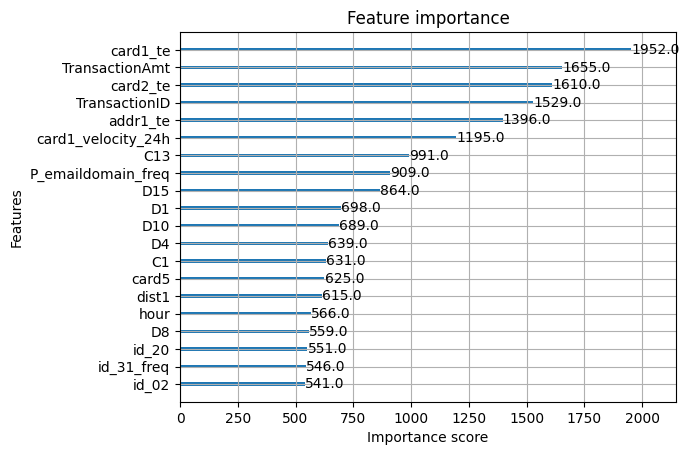

In [ ]:
# Quick way to see what your model actually cares about
xgb.plot_importance(trained_model, max_num_features=20)
plt.show()

In [ ]:
def identify_useless_features(model, X_train, threshold=0.0):
    """
    Identifies features that contribute zero or near-zero importance to the model.
    """
    # 1. Extract the raw importance scores (Gain) from the booster
    booster = model.get_booster()
    importance_dict = booster.get_score(importance_type='gain')

    # 2. Map scores back to ALL original training columns
    # (XGBoost completely leaves out 0-importance columns from get_score)
    all_features = X_train.columns
    full_importance_series = pd.Series(0.0, index=all_features)

    for feat, score in importance_dict.items():
        full_importance_series[feat] = score

    # 3. Filter features below our threshold
    useless_features = full_importance_series[full_importance_series <= threshold].index.tolist()

    print(f"Total features in dataset: {len(all_features)}")
    print(f"Features with zero importance (Gain == 0): {len(useless_features)}")

    return useless_features, full_importance_series

In [ ]:
# Assuming you just finished training 'trained_model' using the module we built...

# 1. Identify the 0-importance features
useless_cols, importance_scores = identify_useless_features(trained_model, X_train)

# 2. Drop them from both Train and Test sets
X_train_lean = X_train.drop(columns=useless_cols)
X_test_lean = X_test.drop(columns=useless_cols)

print(f"Lean training dataset shape: {X_train_lean.shape}")

# 3. Retrain the model on the lean dataset
print("\n--- Retraining Lean Model ---")
lean_model = train_xgboost_model(
    X_train_lean, y_train,
    X_test_lean, y_test,
    model_type='classification'
)

# 4. Evaluate to ensure your AUCPR didn't drop
lean_metrics = evaluate_classification(lean_model, X_test_lean, y_test)

Total features in dataset: 482
Features with zero importance (Gain == 0): 171
Lean training dataset shape: (445173, 311)

--- Retraining Lean Model ---


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:10:13] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:10:13] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-aucpr:0.37945
[100]	validation_0-aucpr:0.53676
[200]	validation_0-aucpr:0.55896
[300]	validation_0-aucpr:0.57172
[400]	validation_0-aucpr:0.57774
[500]	validation_0-aucpr:0.58410
[600]	validation_0-aucpr:0.58987
[700]	validation_0-aucpr:0.59324
[800]	validation_0-aucpr:0.59610


In [ ]:
# Print the top 20 most important features after cleaning
print("\nTop 20 Features by Gain:")
print(importance_scores.sort_values(ascending=False).head(20))


Top 20 Features by Gain:
V258           1011.479553
V257            620.428406
V148            221.898392
V189            123.959236
V187            123.445198
V243            112.472313
V69             104.576607
C14              98.832726
M5_unknown       94.609741
C4               92.533630
C1               78.698547
card1_te         77.845863
V201             70.157013
V283             66.474335
V90              58.188717
V252             50.190220
V172             46.559200
V312             44.647545
ProductCD_H      37.405781
V54              36.885288
dtype: float64


In [ ]:
# Get probabilities instead
y_prob = lean_model.predict_proba(X_test_lean)[:, 1]

# Apply custom threshold
threshold = 0.47  # adjust this
y_pred_custom = (y_prob >= threshold).astype(int)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    140334
           1       0.78      0.43      0.55      5033

    accuracy                           0.98    145367
   macro avg       0.88      0.71      0.77    145367
weighted avg       0.97      0.98      0.97    145367



In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = sm.fit_resample(X_train_lean, y_train)

In [ ]:
# 3. Retrain the model on the lean dataset
print("\n--- Retraining Lean Model ---")
lean_model = train_xgboost_model(
    X_train_sm, y_train_sm,
    X_test_lean, y_test,
    model_type='classification'
)

# 4. Evaluate to ensure your AUCPR didn't drop
lean_metrics = evaluate_classification(lean_model, X_test_lean, y_test)


--- Retraining Lean Model ---


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:25:38] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:25:38] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-aucpr:0.29240
[100]	validation_0-aucpr:0.47386
[200]	validation_0-aucpr:0.51575
[300]	validation_0-aucpr:0.53647
[400]	validation_0-aucpr:0.55177
[500]	validation_0-aucpr:0.56204
[600]	validation_0-aucpr:0.57309
[700]	validation_0-aucpr:0.58005
[800]	validation_0-aucpr:0.58628
[900]	validation_0-aucpr:0.59014
[999]	validation_0-aucpr:0.59546
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    140334
           1       0.79      0.41      0.54      5033

    accuracy                           0.98    145367
   macro avg       0.89      0.70      0.76    145367
weighted avg       0.97      0.98      0.97    145367



In [ ]:
lean_metrics = evaluate_classification(lean_model, X_test_lean, y_test)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    140334
           1       0.79      0.41      0.54      5033

    accuracy                           0.98    145367
   macro avg       0.89      0.70      0.76    145367
weighted avg       0.97      0.98      0.97    145367



In [ ]:
from sklearn.metrics import precision_score, recall_score
# Try the other column
y_prob_fraud = lean_model.predict_proba(X_test_lean)[:, 0]

for t in [0.20, 0.25, 0.30, 0.35, 0.40]:
    y_pred = (y_prob_fraud >= t).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    print(f"Threshold {t:.2f} → Precision: {p:.3f}, Recall: {r:.3f}")

Threshold 0.20 → Precision: 0.025, Recall: 0.722
Threshold 0.25 → Precision: 0.024, Recall: 0.696
Threshold 0.30 → Precision: 0.023, Recall: 0.669
Threshold 0.35 → Precision: 0.023, Recall: 0.646
Threshold 0.40 → Precision: 0.022, Recall: 0.631


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate the existing model
calibrated = CalibratedClassifierCV(lean_model, method='isotonic', cv='prefit')
calibrated.fit(X_test_lean, y_test)  # fit on test since model already trained

# Now get calibrated probabilities
y_prob_cal = calibrated.predict_proba(X_test_lean)[:, 1]

for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred = (y_prob_cal >= t).astype(int)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    print(f"Threshold {t:.2f} → Precision: {p:.3f}, Recall: {r:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Threshold 0.20 → Precision: 0.508, Recall: 0.614
Threshold 0.25 → Precision: 0.595, Recall: 0.555
Threshold 0.30 → Precision: 0.656, Recall: 0.510
Threshold 0.35 → Precision: 0.720, Recall: 0.470
Threshold 0.40 → Precision: 0.731, Recall: 0.462
Threshold 0.45 → Precision: 0.779, Recall: 0.423
Threshold 0.50 → Precision: 0.779, Recall: 0.423


In [ ]:
import shutil
import os

# Mount drive if not already mounted

# 1. Create output directory on Drive
save_dir = './artifacts'
os.makedirs(save_dir, exist_ok=True)

# 2. Save models
import joblib
joblib.dump(lean_model, f'{save_dir}/lean_model.pkl')

# 3. Save lean datasets
import pandas as pd
X_train_lean.to_csv(f'{save_dir}/X_train_lean.csv')
X_test_lean.to_csv(f'{save_dir}/X_test_lean.csv')
pd.Series(y_train).to_csv(f'{save_dir}/y_train.csv')
pd.Series(y_test).to_csv(f'{save_dir}/y_test.csv')

# 4. Zip everything
zip_path = './data/fraud_detection_backup'
shutil.make_archive(zip_path, 'zip', save_dir)

# 5. Move zip to Drive
shutil.move(f'{zip_path}.zip', f'{save_dir}/fraud_detection_backup.zip')

print("Done! Files saved:")
for f in os.listdir(save_dir):
    size = os.path.getsize(f'{save_dir}/{f}') / 1e6
    print(f"  {f}: {size:.1f} MB")

Done! Files saved:
  fraud_detection_backup.zip: 171.9 MB
  lean_model.pkl: 3.7 MB
  X_train_lean.csv: 572.0 MB
  X_test_lean.csv: 187.4 MB
  y_train.csv: 3.9 MB
  y_test.csv: 1.3 MB
